# F1 Tire Degradation Model

Pipeline:
1.  Load race data (fastf1)
2.  Clean laps (accurate, no pits, no outliers)
3.  Build features (LapInStint, StintID, RaceTime, GapAhead/Behind)
4.  Compute degradation signal (DeltaT, SmoothedDeltaT)
5.  Label laps (Clean vs Noisy via gap thresholds)
6.  Add MLP features (lag, diff, rolling std, lap position)
7.  Train MLP v1 → CleanProb
8.  Evaluate MLP v1 (AUC)
9.  Apply CleanProb to full dataset
10. Build regression dataset (LapInStint, Lap², Compound + weights)
11. Train regression (Ridge + Gradient Boosting)
12. Plot smoothed degradation curves
13. Evaluate on out-of-sample race (Canada 2023)
14. Compute telemetry-based metrics → TelemetryScore
15. Generate telemetry labels (CleanLabel_v2)
16. Train MLP v2 on telemetry labels → CleanProb2
17. Evaluate MLP v2 (AUC)
18. Build regression dataset v2 (using CleanProb2)
19. Train Ridge + GB on CleanProb2 dataset
20. Train Random Forest on both CleanProb and CleanProb2 datasets
21. Train basic MLP regressor on both CleanProb and CleanProb2 datasets
22. Compare all 8 regression models

In [33]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import roc_auc_score, mean_squared_error, mean_absolute_error, r2_score

fastf1.Cache.enable_cache('cache')

## Steps 1–4: Data Loading & Preprocessing

In [34]:
RACES_2024 = [
    'Bahrain', 'Saudi Arabia', 'Australia', 'Japan', 'China', 'Miami',
    'Imola', 'Monaco', 'Canada', 'Spain', 'Austria', 'Britain',
    'Hungary', 'Belgium', 'Netherlands', 'Italy', 'Singapore',
    'USA', 'Mexico', 'Brazil', 'Las Vegas', 'Abu Dhabi'
]

TELEMETRY_RACES = ['Bahrain', 'Saudi Arabia', 'Australia', 'Japan', 'China', 'Miami']

COMPOUNDS = ['SOFT', 'MEDIUM', 'HARD']

GAP_FEATURE_COLS = [
    'GapAhead', 'GapBehind',
    'DeltaT_lag1', 'DeltaT_diff',
    'LapTime_rollingStd_3', 'GapAhead_std_3',
    'LapInStint', 'LapFraction',
    'IsFirstLap', 'IsLastLap'
]

TEL_FEATURE_COLS = GAP_FEATURE_COLS + [
    'Speed_std', 'Throttle_std', 'FullThrottle_frac',
    'Brake_events', 'Speed_drop_events'
]


# ── Data loading ───────────────────────────────────────────────────────────────

def _extract_telemetry(lap):
    try:
        tel = lap.get_telemetry()
        if tel is None or len(tel) < 50:
            raise ValueError("Insufficient telemetry")
        return {
            'Speed_std':         tel['Speed'].std(),
            'Throttle_std':      tel['Throttle'].std(),
            'FullThrottle_frac': (tel['Throttle'] > 95).mean(),
            'Brake_events':      (tel['Brake'].diff() > 0.5).sum(),
            'Speed_drop_events': (tel['Speed'].diff() < -15).sum()
        }
    except Exception:
        return {k: np.nan for k in ['Speed_std', 'Throttle_std', 'FullThrottle_frac',
                                     'Brake_events', 'Speed_drop_events']}


def load_race_laps(races, year=2024, telemetry=False):
    all_laps = []
    for race in races:
        try:
            session = fastf1.get_session(year, race, 'R')
            session.load(laps=True, telemetry=telemetry, weather=False)
            laps = session.laps.copy()
            laps['Race'] = race
            if telemetry:
                features = [_extract_telemetry(lap) for _, lap in laps.iterlaps()]
                laps = pd.concat([laps, pd.DataFrame(features, index=laps.index)], axis=1)
            all_laps.append(laps)
        except Exception as e:
            print(f"Skipping {race}: {e}")
    df = pd.concat(all_laps, ignore_index=True)
    print(f"Loaded {len(races)} races → {df.shape[0]} laps")
    return df


# ── Cleaning ───────────────────────────────────────────────────────────────────

def clean_lap_data(df):
    """Remove inaccurate, pit, and unrealistic laps. Convert LapTime to seconds."""
    df = df.copy()
    df = df[df['IsAccurate'] == True]
    df = df[df['PitInTime'].isna() & df['PitOutTime'].isna()]
    df = df.dropna(subset=['LapTime', 'Compound', 'Driver', 'Stint'])
    df['LapTime_s'] = df['LapTime'].dt.total_seconds()
    df = df[df['LapTime_s'] < 200]
    print(f"After cleaning: {df.shape[0]} laps")
    return df



def remove_outliers_by_compound(df):
    """Remove laps outside 3σ per compound (prevents cross-compound bias)."""
    initial = len(df)
    def filter_group(g):
        mean, std = g['LapTime_s'].mean(), g['LapTime_s'].std()
        return g[(g['LapTime_s'] >= mean - 3*std) & (g['LapTime_s'] <= mean + 3*std)]
    df = df.groupby('Compound', group_keys=False).apply(
    lambda g: filter_group(g)
).reset_index(drop=True)
    print(f"Removed {initial - len(df)} outliers → {len(df)} laps")
    return df


# ── Feature engineering ────────────────────────────────────────────────────────

def create_stint_features(df):
    """Add LapInStint and a unique StintID per driver/stint/race."""
    df = df.copy().sort_values(['Race', 'Driver', 'Stint', 'LapNumber']).reset_index(drop=True)
    df['LapInStint'] = df.groupby(['Race', 'Driver', 'Stint']).cumcount() + 1
    df['StintID'] = (
        df['Race'].astype(str) + "_" +
        df['Driver'].astype(str) + "_S" +
        df['Stint'].astype(int).astype(str)
    )
    return df


def compute_gaps(df):
    """Compute GapAhead and GapBehind from cumulative race time."""
    df['RaceTime'] = df.groupby(['Race', 'Driver'])['LapTime_s'].cumsum()
    gap_frames = []
    for race in df['Race'].unique():
        race_df = df[df['Race'] == race]
        for lap in race_df['LapNumber'].unique():
            lap_df = race_df[race_df['LapNumber'] == lap].copy().sort_values('RaceTime')
            lap_df['GapAhead'] = lap_df['RaceTime'].diff()
            lap_df['GapBehind'] = lap_df['RaceTime'].diff(-1).abs()
            gap_frames.append(lap_df)
    return pd.concat(gap_frames).reset_index(drop=True)


# %%


def compute_degradation_features(df):
    """DeltaT = lap time minus the best lap in the stint. Raw signal, no smoothing."""
    df = df.copy()
    df['BestLapTime'] = df.groupby('StintID')['LapTime_s'].transform('min')
    df['DeltaT'] = df['LapTime_s'] - df['BestLapTime']
    return df


def add_classifier_features(df):
    """Lag, diff, rolling std, gap stability, and stint position features."""
    df = df.copy()
    df['DeltaT_lag1'] = df.groupby('StintID')['DeltaT'].shift(1)
    df['DeltaT_diff'] = df['DeltaT'] - df['DeltaT_lag1']
    df['LapTime_rollingStd_3'] = df.groupby('StintID')['LapTime_s'].transform(
        lambda x: x.rolling(window=3, min_periods=1).std()
    )
    df['GapAhead_std_3'] = df.groupby('StintID')['GapAhead'].transform(
        lambda x: x.rolling(window=3, min_periods=1).std()
    )
    stint_max = df.groupby('StintID')['LapInStint'].transform('max')
    df['LapFraction'] = df['LapInStint'] / stint_max
    df['IsFirstLap'] = (df['LapInStint'] == 1).astype(int)
    df['IsLastLap'] = df.groupby('StintID')['LapInStint'].transform(
        lambda x: x == x.max()
    ).astype(int)
    return df


def preprocess_pipeline(df):
    df = clean_lap_data(df)
    df = remove_outliers_by_compound(df)
    df = create_stint_features(df)
    df = compute_gaps(df)
    df = compute_degradation_features(df)
    df = add_classifier_features(df)
    return df


# ── Run ────────────────────────────────────────────────────────────────────────

df = load_race_laps(RACES_2024)
df = preprocess_pipeline(df)

df.head()

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached dat

Loaded 22 races → 24574 laps
After cleaning: 21739 laps
Removed 16 outliers → 21723 laps


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,GapBehind,BestLapTime,DeltaT,DeltaT_lag1,DeltaT_diff,LapTime_rollingStd_3,GapAhead_std_3,LapFraction,IsFirstLap,IsLastLap
0,0 days 01:03:22.646000,SAI,55,0 days 00:01:28.995000,4.0,1.0,NaT,NaT,0 days 00:00:18.166000,0 days 00:00:38.123000,...,0.015,88.909,0.086,NaN,NaN,NaN,NaN,0.047619,1,0
1,0 days 01:03:19.901000,NOR,4,0 days 00:01:29.010000,4.0,1.0,NaT,NaT,0 days 00:00:18.280000,0 days 00:00:38.144000,...,0.192,88.860,0.150,NaN,NaN,NaN,NaN,0.045455,1,0
2,0 days 01:03:26.718000,MAG,20,0 days 00:01:29.202000,4.0,1.0,NaT,NaT,0 days 00:00:17.916000,0 days 00:00:37.544000,...,0.071,89.202,0.000,NaN,NaN,NaN,NaN,0.125000,1,0
3,0 days 01:03:27.673000,LEC,16,0 days 00:01:29.273000,4.0,1.0,NaT,NaT,0 days 00:00:18.001000,0 days 00:00:38.230000,...,0.075,89.273,0.000,NaN,NaN,NaN,NaN,0.062500,1,0
4,0 days 01:03:25.509000,HUL,27,0 days 00:01:29.348000,4.0,1.0,NaT,NaT,0 days 00:00:18.003000,0 days 00:00:37.685000,...,0.058,89.348,0.000,NaN,NaN,NaN,NaN,0.111111,1,0


### Dataset overview

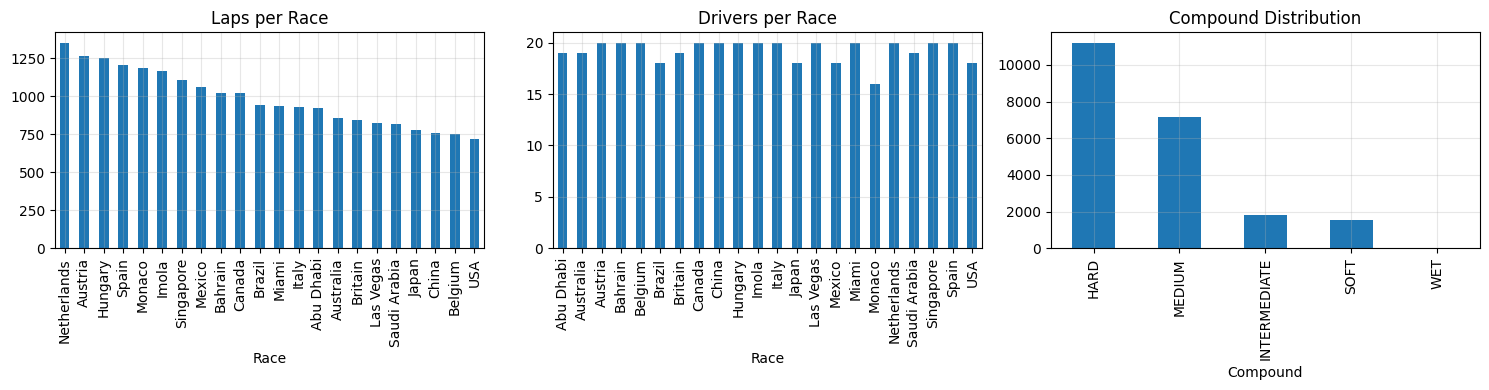

Races: 22 | Drivers: 24 | Laps: 21723


In [35]:
def plot_dataset_overview(df):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    df['Race'].value_counts().plot(kind='bar', ax=axes[0], title='Laps per Race')
    df.groupby('Race')['Driver'].nunique().plot(kind='bar', ax=axes[1], title='Drivers per Race')
    df['Compound'].value_counts().plot(kind='bar', ax=axes[2], title='Compound Distribution')
    for ax in axes:
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"Races: {df['Race'].nunique()} | Drivers: {df['Driver'].nunique()} | Laps: {len(df)}")

def plot_dataset_overview(df):
    if not {'Race', 'Driver', 'Compound'}.issubset(df.columns):
        try:
            df = preprocess_pipeline(df)
        except Exception as exc:
            raise KeyError(
                "Dataset must contain 'Race', 'Driver', and 'Compound'. "
                "Run preprocess_pipeline() first."
            ) from exc

    df = df.copy()
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    df['Race'].value_counts().plot(kind='bar', ax=axes[0], title='Laps per Race')
    df.groupby('Race')['Driver'].nunique().plot(kind='bar', ax=axes[1], title='Drivers per Race')
    df['Compound'].value_counts().plot(kind='bar', ax=axes[2], title='Compound Distribution')
    for ax in axes:
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"Races: {df['Race'].nunique()} | Drivers: {df['Driver'].nunique()} | Laps: {len(df)}")

plot_dataset_overview(df)

## Step 5: Gap-Based Cleanliness Labels

In [36]:
def create_clean_labels(df, threshold=3.0, margin=0.15):
    """
    Clean (1): both gaps > upper bound → free air.
    Noisy (0): either gap < lower bound → in traffic.
    Borderline laps are dropped.
    """
    df = df.copy()
    lower, upper = threshold * (1 - margin), threshold * (1 + margin)
    df['CleanLabel'] = np.nan
    df.loc[(df['GapAhead'] > upper) & (df['GapBehind'] > upper), 'CleanLabel'] = 1
    df.loc[(df['GapAhead'] < lower) | (df['GapBehind'] < lower), 'CleanLabel'] = 0
    df_labeled = df.dropna(subset=['CleanLabel'])
    print(f"Labeled {len(df_labeled)} laps")
    print(df_labeled['CleanLabel'].value_counts(normalize=True).round(3))
    return df, df_labeled

df, df_labeled = create_clean_labels(df)

Labeled 18604 laps
CleanLabel
0.0    0.742
1.0    0.258
Name: proportion, dtype: float64


## Steps 6–9: MLP v1 — Gap-Based Cleanliness Classifier

Train: (13199, 10) | Test: (3588, 10)
  Epoch   0 | Loss: 0.7263
  Epoch  10 | Loss: 0.6532
  Epoch  20 | Loss: 0.5949
  Epoch  30 | Loss: 0.5391
  Epoch  40 | Loss: 0.4926
  Epoch  50 | Loss: 0.4652
  Epoch  60 | Loss: 0.4434
  Epoch  70 | Loss: 0.4267
  Epoch  80 | Loss: 0.4137
  Epoch  90 | Loss: 0.4022
Training complete

MLP v1 AUC: 0.9246


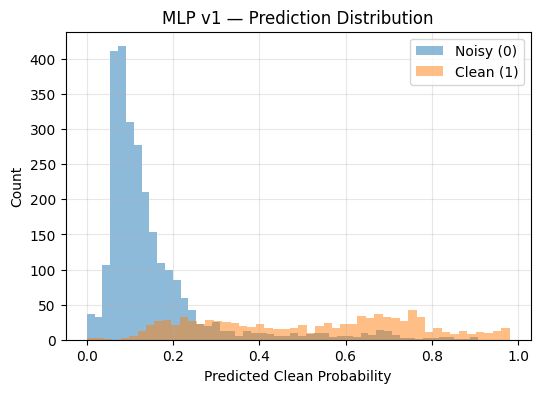

Added 'CleanProb' | mean=0.256


In [37]:
class CleanLapMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


def build_classifier_dataset(df, feature_cols, label_col='CleanLabel'):
    df_model = df.dropna(subset=feature_cols + [label_col]).copy()
    train_stints, test_stints = train_test_split(
        df_model['StintID'].unique(), test_size=0.2, random_state=42
    )
    train_df = df_model[df_model['StintID'].isin(train_stints)]
    test_df  = df_model[df_model['StintID'].isin(test_stints)]
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_df[feature_cols])
    X_test  = scaler.transform(test_df[feature_cols])
    print(f"Train: {X_train.shape} | Test: {X_test.shape}")
    return X_train, X_test, train_df[label_col], test_df[label_col], scaler


def train_mlp(model, X_train, y_train, epochs=100, lr=1e-3):
    X_t = torch.tensor(X_train, dtype=torch.float32)
    y_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_t), y_t)
        loss.backward()
        optimizer.step()
        if epoch % 10 == 0:
            print(f"  Epoch {epoch:3d} | Loss: {loss.item():.4f}")
    print("Training complete")
    return model


def evaluate_mlp(model, X_test, y_test, label='MLP'):
    """Steps 8 / 17: AUC and prediction distribution."""
    model.eval()
    with torch.no_grad():
        y_pred = model(torch.tensor(X_test, dtype=torch.float32)).numpy().flatten()
    auc = roc_auc_score(y_test, y_pred)
    print(f"\n{label} AUC: {auc:.4f}")
    plt.figure(figsize=(6, 4))
    plt.hist(y_pred[y_test == 0], bins=50, alpha=0.5, label='Noisy (0)')
    plt.hist(y_pred[y_test == 1], bins=50, alpha=0.5, label='Clean (1)')
    plt.xlabel("Predicted Clean Probability")
    plt.ylabel("Count")
    plt.title(f"{label} — Prediction Distribution")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    return y_pred


def add_clean_probability(model, df, scaler, feature_cols, out_col='CleanProb'):
    """Step 9: Score every lap using the trained MLP."""
    model.eval()
    df_out = df.dropna(subset=feature_cols).copy()
    X = scaler.transform(df_out[feature_cols])
    with torch.no_grad():
        df_out[out_col] = model(torch.tensor(X, dtype=torch.float32)).numpy().flatten()
    print(f"Added '{out_col}' | mean={df_out[out_col].mean():.3f}")
    return df_out


# ── Train MLP v1 ───────────────────────────────────────────────────────────────

X_tr1, X_te1, y_tr1, y_te1, scaler1 = build_classifier_dataset(df_labeled, GAP_FEATURE_COLS)
mlp1 = CleanLapMLP(input_dim=len(GAP_FEATURE_COLS))
mlp1 = train_mlp(mlp1, X_tr1, y_tr1)                    # Step 7
evaluate_mlp(mlp1, X_te1, y_te1, label='MLP v1')         # Step 8
df_with_prob = add_clean_probability(mlp1, df, scaler1, GAP_FEATURE_COLS, out_col='CleanProb')  # Step 9

## Steps 10–12: Regression v1 — Weighted Degradation Model

In [38]:


def build_regression_dataset(df, encoder=None, weight_col='CleanProb', include_race=True):
    X_num = np.column_stack([df['LapInStint'], df['LapInStint']**2])
    cat_cols = ['Compound', 'Race'] if include_race else ['Compound']
    if encoder is None:
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        X_cat = encoder.fit_transform(df[cat_cols])
    else:
        X_cat = encoder.transform(df[cat_cols])
    X = np.hstack([X_num, X_cat])
    y = df['DeltaT'].values          # ← was SmoothedDeltaT
    w = df[weight_col].values if weight_col in df.columns else np.ones(len(df))
    print(f"Regression dataset: {X.shape}, weight_col='{weight_col}'")
    return X, y, w, encoder

def train_regression_models(X, y, w):
    ridge = Ridge(alpha=1.0)
    ridge.fit(X, y, sample_weight=w)
    gb = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
    gb.fit(X, y, sample_weight=w)
    print("Ridge and Gradient Boosting trained")
    return ridge, gb


def eval_regression(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"  {name:<50} RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")
    return {'model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}


# ── Train regression v1 ────────────────────────────────────────────────────────

X_reg1, y_reg1, w_reg1, encoder1 = build_regression_dataset(df_with_prob, weight_col='CleanProb')
ridge1, gb1 = train_regression_models(X_reg1, y_reg1, w_reg1)   # Steps 10–11

Regression dataset: (18164, 29), weight_col='CleanProb'
Ridge and Gradient Boosting trained


### Step 12: Degradation curve visualisation

/Users/aayushshah/Library/Python/3.13/lib/python/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
/Users/aayushshah/Library/Python/3.13/lib/python/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
/Users/aayushshah/Library/Python/3.13/lib/python/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


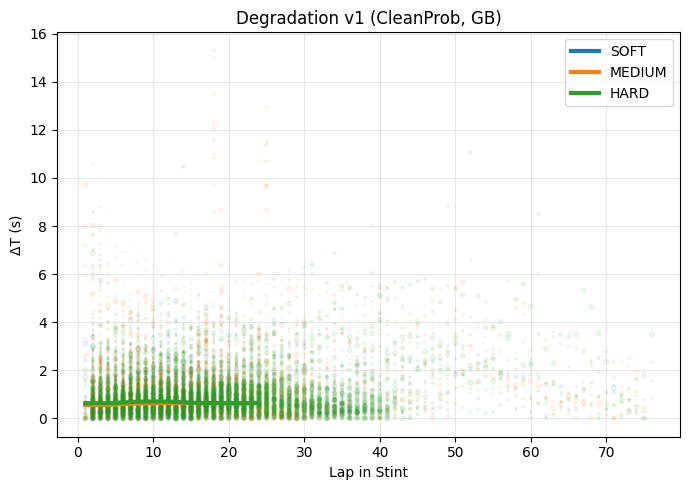

In [39]:
# %%
def plot_degradation_curves(df, model, encoder, weight_col='CleanProb',
                             title="Tire Degradation", sigma=1.5):
    """
    Scatter: raw DeltaT, point size ∝ CleanProb (cleaner laps more visible).
    Curve: model prediction, lightly smoothed for readability only.
    """
    lap_range = np.arange(1, 25)
    plt.figure(figsize=(7, 5))
    for comp in COMPOUNDS:
        subset = df[df['Compound'] == comp]
        sizes = 15 * subset[weight_col] if weight_col in subset.columns else 5
        plt.scatter(subset['LapInStint'], subset['DeltaT'], s=sizes, alpha=0.08)
        X_num = np.column_stack([lap_range, lap_range**2])
        X_cat = encoder.transform([[comp, df['Race'].iloc[0]]] * len(lap_range))
        y_pred = model.predict(np.hstack([X_num, X_cat]))
        y_pred = gaussian_filter1d(y_pred, sigma=sigma)   # display smoothing only
        plt.plot(lap_range, y_pred, linewidth=3, label=comp)
    plt.xlabel("Lap in Stint")
    plt.ylabel("ΔT (s)")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
plot_degradation_curves(df_with_prob, gb1, encoder1, title="Degradation v1 (CleanProb, GB)")

## Step 13: Out-of-Sample Evaluation — Canada 2023

**Finding:** R² is strongly negative on an unseen race/year. Stint position + compound alone
cannot capture track-level degradation behaviour. Tyre degradation is highly track-dependent,
and without track context the model has no way to adapt.

**Fix:** Race is added as a categorical feature and the model is retrained on the full 2024
calendar (steps 18–19). This captures track-specific degradation behaviour and substantially
improves within-distribution performance.

**Remaining limitation:** Even with race encoding, performance on a different season (2023) stays
weak. Race labels are a proxy — they don't encode true track physics, and seasonal distribution
shift (car performance, setups, conditions) further degrades generalisation.

In [40]:
session_oos = fastf1.get_session(2023, 'Canada', 'R')
session_oos.load(laps=True, telemetry=False, weather=False)
df_oos = session_oos.laps.copy()
df_oos['Race'] = 'Canada_2023'
df_oos = preprocess_pipeline(df_oos)
df_oos = add_clean_probability(mlp1, df_oos, scaler1, GAP_FEATURE_COLS, out_col='CleanProb')
X_oos, y_oos, _, _ = build_regression_dataset(df_oos, encoder=encoder1, weight_col='CleanProb')

print("\n── Out-of-sample: Canada 2023 (regression v1) ──")
oos_results = []
oos_results.append(eval_regression("Ridge v1 (OOS Canada 2023)", y_oos, ridge1.predict(X_oos)))
oos_results.append(eval_regression("GB v1    (OOS Canada 2023)", y_oos, gb1.predict(X_oos)))

print("\n── In-sample sanity check ──")
oos_results.append(eval_regression("Ridge v1 (in-sample)", y_reg1, ridge1.predict(X_reg1)))
oos_results.append(eval_regression("GB v1    (in-sample)", y_reg1, gb1.predict(X_reg1)))

core           INFO 	Loading data for Canadian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '22'
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '14', '44', '16', '55', '11', '23', '31', '18', '77', '81', '10', '4', '22', '27', '24', '20', '21', '63', '2']
/var/folders/gf/gkj79xpx1kn1n87by4c9wwnr0000gn/T/ipykernel_37055/1225138837.py:85: FutureWarning: DataFrameGroupBy.apply operated on the grouping col

After cleaning: 1127 laps
Removed 1 outliers → 1126 laps
Added 'CleanProb' | mean=0.369
Regression dataset: (951, 29), weight_col='CleanProb'

── Out-of-sample: Canada 2023 (regression v1) ──
  Ridge v1 (OOS Canada 2023)                         RMSE=0.6553  MAE=0.5857  R²=-1.1005
  GB v1    (OOS Canada 2023)                         RMSE=0.5640  MAE=0.4914  R²=-0.5557

── In-sample sanity check ──
  Ridge v1 (in-sample)                               RMSE=1.2335  MAE=0.7191  R²=0.2535
  GB v1    (in-sample)                               RMSE=1.0956  MAE=0.6517  R²=0.4111


## Step 14: Telemetry-Based Cleanliness Metrics

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_co

Loaded 6 races → 6078 laps
After cleaning: 5178 laps
Removed 11 outliers → 5167 laps


/var/folders/gf/gkj79xpx1kn1n87by4c9wwnr0000gn/T/ipykernel_37055/1225138837.py:85: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Compound', group_keys=False).apply(


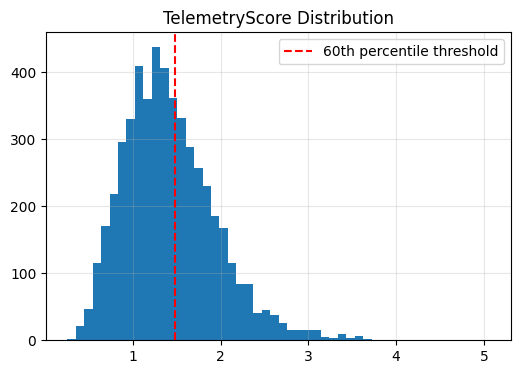

       TelemetryScore
count        5165.000
mean            1.418
std             0.527
min             0.250
25%             1.047
50%             1.350
75%             1.719
max             5.070


In [41]:
def add_telemetry_score(df):
    """
    Normalise each telemetry metric within the stint (z-score) then combine as a
    weighted sum. High score = erratic driving = noisy lap.
    """
    tel_cols = ['Speed_std', 'Throttle_std', 'Brake_events', 'Speed_drop_events', 'FullThrottle_frac']
    for col in tel_cols:
        df[col + '_z'] = df.groupby('StintID')[col].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-6)
        )
    df['TelemetryScore'] = (
        0.5 * df['Speed_std_z'].abs() +
        0.5 * df['Throttle_std_z'].abs() +
        0.3 * df['Brake_events_z'].abs() +
        0.3 * df['Speed_drop_events_z'].abs() +
        0.4 * (1 - df['FullThrottle_frac'])
    )
    threshold = df['TelemetryScore'].quantile(0.6)
    plt.figure(figsize=(6, 4))
    plt.hist(df['TelemetryScore'], bins=50)
    plt.axvline(threshold, color='red', linestyle='--', label='60th percentile threshold')
    plt.title("TelemetryScore Distribution")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    print(df[['TelemetryScore']].describe().round(3))
    return df, threshold

df_tel = load_race_laps(TELEMETRY_RACES, telemetry=True)
df_tel = preprocess_pipeline(df_tel)
df_tel, tel_threshold = add_telemetry_score(df_tel)

## Step 15: Telemetry-Based Labels (CleanLabel_v2)

In [42]:
def create_telemetry_labels(df, threshold):
    """
    Clean (1): TelemetryScore below the 60th-percentile threshold → smooth driving.
    Noisy (0): above threshold, or lap under yellow/safety car (TrackStatus ≠ '1').
    """
    df = df.copy()
    df['CleanLabel_v2'] = (df['TelemetryScore'] < threshold).astype(int)
    if 'TrackStatus' in df.columns:
        df.loc[df['TrackStatus'] != '1', 'CleanLabel_v2'] = 0
    print("CleanLabel_v2 distribution:")
    print(df['CleanLabel_v2'].value_counts(normalize=True).round(3))
    return df

df_tel = create_telemetry_labels(df_tel, tel_threshold)

CleanLabel_v2 distribution:
CleanLabel_v2
1    0.591
0    0.409
Name: proportion, dtype: float64


## Steps 16–17: MLP v2 — Telemetry-Based Classifier

Train: (3362, 15) | Test: (904, 15)
  Epoch   0 | Loss: 0.6859
  Epoch  10 | Loss: 0.6696
  Epoch  20 | Loss: 0.6620
  Epoch  30 | Loss: 0.6532
  Epoch  40 | Loss: 0.6488
  Epoch  50 | Loss: 0.6445
  Epoch  60 | Loss: 0.6401
  Epoch  70 | Loss: 0.6348
  Epoch  80 | Loss: 0.6345
  Epoch  90 | Loss: 0.6325
Training complete

MLP v2 AUC: 0.6233


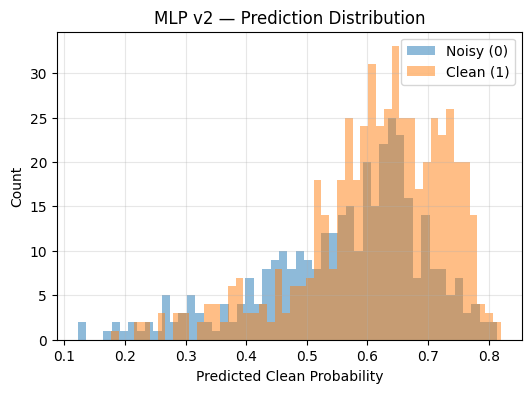

array([0.45174772, 0.6891824 , 0.7341887 , 0.525343  , 0.66134953,
       0.6186009 , 0.65682834, 0.68231475, 0.6663889 , 0.590374  ,
       0.72596705, 0.6037984 , 0.65641725, 0.6509672 , 0.5036249 ,
       0.7113015 , 0.65726143, 0.5601283 , 0.72848284, 0.67205507,
       0.59417325, 0.69595915, 0.64061505, 0.55867255, 0.6924289 ,
       0.24392551, 0.7280404 , 0.794207  , 0.70211655, 0.7397965 ,
       0.65941954, 0.70054287, 0.66460234, 0.71296877, 0.6456533 ,
       0.7121057 , 0.7139319 , 0.7289455 , 0.6313271 , 0.77813566,
       0.6935033 , 0.7514239 , 0.6473504 , 0.6116475 , 0.6855274 ,
       0.78052825, 0.67098063, 0.71561104, 0.74710083, 0.7066979 ,
       0.72843707, 0.55410475, 0.6583226 , 0.6806644 , 0.73624825,
       0.42022058, 0.4095073 , 0.6808035 , 0.7118724 , 0.73447424,
       0.6073212 , 0.70385176, 0.73014426, 0.7332537 , 0.6740022 ,
       0.598087  , 0.67095107, 0.6896678 , 0.7159782 , 0.718163  ,
       0.5897596 , 0.6588694 , 0.68697417, 0.74215084, 0.64646

In [43]:
df_tel_labeled = df_tel.dropna(subset=TEL_FEATURE_COLS + ['CleanLabel_v2']).copy()

X_tr2, X_te2, y_tr2, y_te2, scaler2 = build_classifier_dataset(
    df_tel_labeled, TEL_FEATURE_COLS, label_col='CleanLabel_v2'
)
mlp2 = CleanLapMLP(input_dim=len(TEL_FEATURE_COLS))
mlp2 = train_mlp(mlp2, X_tr2, y_tr2)                    # Step 16
evaluate_mlp(mlp2, X_te2, y_te2, label='MLP v2')         # Step 17

## Steps 18–19: Regression v2 — Weighted by CleanProb2

Added 'CleanProb2' | mean=0.597
Regression dataset: (4266, 11), weight_col='CleanProb2'
Ridge and Gradient Boosting trained


/Users/aayushshah/Library/Python/3.13/lib/python/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
/Users/aayushshah/Library/Python/3.13/lib/python/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
/Users/aayushshah/Library/Python/3.13/lib/python/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


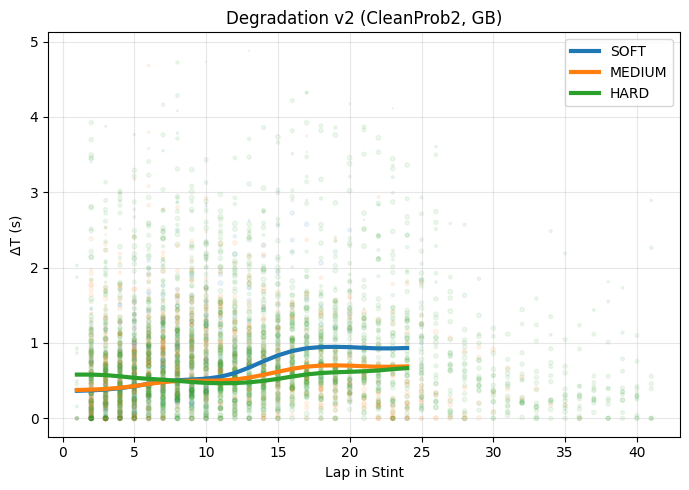

In [44]:
df_tel_with_prob = add_clean_probability(
    mlp2, df_tel, scaler2, TEL_FEATURE_COLS, out_col='CleanProb2'
)

X_reg2, y_reg2, w_reg2, encoder2 = build_regression_dataset(
    df_tel_with_prob, weight_col='CleanProb2'
)
ridge2, gb2 = train_regression_models(X_reg2, y_reg2, w_reg2)   # Step 19

plot_degradation_curves(
    df_tel_with_prob, gb2, encoder2,
    weight_col='CleanProb2',
    title="Degradation v2 (CleanProb2, GB)"
)

## Step 20: Random Forest on Both Datasets

In [45]:
def train_random_forest(X, y, w):
    rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
    rf.fit(X, y, sample_weight=w)
    print("Random Forest trained")
    return rf

rf1 = train_random_forest(X_reg1, y_reg1, w_reg1)   # CleanProb weights
rf2 = train_random_forest(X_reg2, y_reg2, w_reg2)   # CleanProb2 weights

Random Forest trained
Random Forest trained


## Step 21: MLP Regressor on Both Datasets

In [46]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)


def train_mlp_regressor(X, y, w, epochs=100, lr=1e-3):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    w_t = torch.tensor(w, dtype=torch.float32).view(-1, 1)
    model = MLPRegressor(input_dim=X.shape[1])
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = ((model(X_t) - y_t)**2 * w_t).mean()   # weighted MSE
        loss.backward()
        optimizer.step()
        if epoch % 10 == 0:
            print(f"  Epoch {epoch:3d} | Loss: {loss.item():.4f}")
    print("MLP regressor training complete")
    return model


def predict_mlp_regressor(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X, dtype=torch.float32)).numpy().flatten()


reg_scaler1 = StandardScaler()
X_reg1_sc = reg_scaler1.fit_transform(X_reg1)

reg_scaler2 = StandardScaler()
X_reg2_sc = reg_scaler2.fit_transform(X_reg2)

mlp_reg1 = train_mlp_regressor(X_reg1_sc, y_reg1, w_reg1)   # CleanProb weights
mlp_reg2 = train_mlp_regressor(X_reg2_sc, y_reg2, w_reg2)   # CleanProb2 weights

  Epoch   0 | Loss: 0.5969
  Epoch  10 | Loss: 0.4064
  Epoch  20 | Loss: 0.3427
  Epoch  30 | Loss: 0.3178
  Epoch  40 | Loss: 0.2950
  Epoch  50 | Loss: 0.2856
  Epoch  60 | Loss: 0.2819
  Epoch  70 | Loss: 0.2782
  Epoch  80 | Loss: 0.2740
  Epoch  90 | Loss: 0.2718
MLP regressor training complete
  Epoch   0 | Loss: 0.7372
  Epoch  10 | Loss: 0.3981
  Epoch  20 | Loss: 0.2883
  Epoch  30 | Loss: 0.2528
  Epoch  40 | Loss: 0.2275
  Epoch  50 | Loss: 0.2125
  Epoch  60 | Loss: 0.2025
  Epoch  70 | Loss: 0.1970
  Epoch  80 | Loss: 0.1927
  Epoch  90 | Loss: 0.1901
MLP regressor training complete


## Step 22: Full Comparison — 8 Regression Models

| # | Model       | Weights          |
|---|-------------|-----------------|
| 1 | Ridge v1    | CleanProb (gap) |
| 2 | GB v1       | CleanProb (gap) |
| 3 | RF v1       | CleanProb (gap) |
| 4 | MLP-Reg v1  | CleanProb (gap) |
| 5 | Ridge v2    | CleanProb2 (telemetry) |
| 6 | GB v2       | CleanProb2 (telemetry) |
| 7 | RF v2       | CleanProb2 (telemetry) |
| 8 | MLP-Reg v2  | CleanProb2 (telemetry) |

In [47]:
print("\n" + "="*75)
print("REGRESSION MODEL COMPARISON — IN-SAMPLE")
print("="*75)

all_results = []
all_results.append(eval_regression("1. Ridge v1    (CleanProb,  gap)",       y_reg1, ridge1.predict(X_reg1)))
all_results.append(eval_regression("2. GB v1       (CleanProb,  gap)",       y_reg1, gb1.predict(X_reg1)))
all_results.append(eval_regression("3. RF v1       (CleanProb,  gap)",       y_reg1, rf1.predict(X_reg1)))
all_results.append(eval_regression("4. MLP-Reg v1  (CleanProb,  gap)",       y_reg1, predict_mlp_regressor(mlp_reg1, X_reg1_sc)))
all_results.append(eval_regression("5. Ridge v2    (CleanProb2, telemetry)", y_reg2, ridge2.predict(X_reg2)))
all_results.append(eval_regression("6. GB v2       (CleanProb2, telemetry)", y_reg2, gb2.predict(X_reg2)))
all_results.append(eval_regression("7. RF v2       (CleanProb2, telemetry)", y_reg2, rf2.predict(X_reg2)))
all_results.append(eval_regression("8. MLP-Reg v2  (CleanProb2, telemetry)", y_reg2, predict_mlp_regressor(mlp_reg2, X_reg2_sc)))

print("\n" + "="*75)
print("SUMMARY TABLE")
print("="*75)
print(pd.DataFrame(all_results).set_index('model').to_string())


REGRESSION MODEL COMPARISON — IN-SAMPLE
  1. Ridge v1    (CleanProb,  gap)                   RMSE=1.2335  MAE=0.7191  R²=0.2535
  2. GB v1       (CleanProb,  gap)                   RMSE=1.0956  MAE=0.6517  R²=0.4111
  3. RF v1       (CleanProb,  gap)                   RMSE=1.0428  MAE=0.6336  R²=0.4665
  4. MLP-Reg v1  (CleanProb,  gap)                   RMSE=1.2024  MAE=0.6949  R²=0.2906
  5. Ridge v2    (CleanProb2, telemetry)             RMSE=0.6529  MAE=0.4710  R²=0.1979
  6. GB v2       (CleanProb2, telemetry)             RMSE=0.5823  MAE=0.4112  R²=0.3621
  7. RF v2       (CleanProb2, telemetry)             RMSE=0.5666  MAE=0.4005  R²=0.3959
  8. MLP-Reg v2  (CleanProb2, telemetry)             RMSE=0.6100  MAE=0.4336  R²=0.2998

SUMMARY TABLE
                                            RMSE       MAE        R2
model                                                               
1. Ridge v1    (CleanProb,  gap)        1.233481  0.719107  0.253526
2. GB v1       (CleanProb,  gap) 

In [48]:
session_oos23 = fastf1.get_session(2023, 'Bahrain', 'R')
session_oos23.load(laps=True, telemetry=True, weather=False)

df_oos23 = session_oos23.laps.copy()
df_oos23['Race'] = 'Bahrain'  # must match a race the encoder has seen

tel_features = [_extract_telemetry(lap) for _, lap in df_oos23.iterlaps()]
df_oos23 = pd.concat([df_oos23, pd.DataFrame(tel_features, index=df_oos23.index)], axis=1)
df_oos23 = preprocess_pipeline(df_oos23)

print(f"OOS laps: {len(df_oos23)} | Telemetry coverage: {df_oos23['Speed_std'].notna().mean():.1%}")

# ── Score with both MLPs ───────────────────────────────────────────────────────
df_oos23 = add_clean_probability(mlp1, df_oos23, scaler1, GAP_FEATURE_COLS,  out_col='CleanProb')
df_oos23 = add_clean_probability(mlp2, df_oos23, scaler2, TEL_FEATURE_COLS,  out_col='CleanProb2')

# ── Build feature matrices (reuse trained encoders) ───────────────────────────
X_oos_v1, y_oos, _, _ = build_regression_dataset(df_oos23, encoder=encoder1, weight_col='CleanProb')
X_oos_v2, _,    _, _ = build_regression_dataset(df_oos23, encoder=encoder2, weight_col='CleanProb2')

X_oos_v1_sc = reg_scaler1.transform(X_oos_v1)
X_oos_v2_sc = reg_scaler2.transform(X_oos_v2)

# ── Evaluate all 8 models ─────────────────────────────────────────────────────
print("\n" + "="*75)
print("OUT-OF-SAMPLE COMPARISON — Bahrain 2023")
print("="*75)

oos_results = []
oos_results.append(eval_regression("1. Ridge v1    (CleanProb,  gap)",       y_oos, ridge1.predict(X_oos_v1)))
oos_results.append(eval_regression("2. GB v1       (CleanProb,  gap)",       y_oos, gb1.predict(X_oos_v1)))
oos_results.append(eval_regression("3. RF v1       (CleanProb,  gap)",       y_oos, rf1.predict(X_oos_v1)))
oos_results.append(eval_regression("4. MLP-Reg v1  (CleanProb,  gap)",       y_oos, predict_mlp_regressor(mlp_reg1, X_oos_v1_sc)))
oos_results.append(eval_regression("5. Ridge v2    (CleanProb2, telemetry)", y_oos, ridge2.predict(X_oos_v2)))
oos_results.append(eval_regression("6. GB v2       (CleanProb2, telemetry)", y_oos, gb2.predict(X_oos_v2)))
oos_results.append(eval_regression("7. RF v2       (CleanProb2, telemetry)", y_oos, rf2.predict(X_oos_v2)))
oos_results.append(eval_regression("8. MLP-Reg v2  (CleanProb2, telemetry)", y_oos, predict_mlp_regressor(mlp_reg2, X_oos_v2_sc)))

print("\n" + "="*75)
print("SUMMARY TABLE")
print("="*75)
print(pd.DataFrame(oos_results).set_index('model').to_string())

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']


After cleaning: 914 laps
Removed 8 outliers → 906 laps
OOS laps: 906 | Telemetry coverage: 100.0%
Added 'CleanProb' | mean=0.251
Added 'CleanProb2' | mean=0.627
Regression dataset: (732, 29), weight_col='CleanProb'
Regression dataset: (732, 11), weight_col='CleanProb2'

OUT-OF-SAMPLE COMPARISON — Bahrain 2023
  1. Ridge v1    (CleanProb,  gap)                   RMSE=0.6212  MAE=0.5028  R²=-0.1966
  2. GB v1       (CleanProb,  gap)                   RMSE=0.5549  MAE=0.4387  R²=0.0453
  3. RF v1       (CleanProb,  gap)                   RMSE=0.5712  MAE=0.4500  R²=-0.0116
  4. MLP-Reg v1  (CleanProb,  gap)                   RMSE=0.6238  MAE=0.5072  R²=-0.2067
  5. Ridge v2    (CleanProb2, telemetry)             RMSE=0.5601  MAE=0.4180  R²=0.0272
  6. GB v2       (CleanProb2, telemetry)             RMSE=0.5102  MAE=0.3764  R²=0.1927


/var/folders/gf/gkj79xpx1kn1n87by4c9wwnr0000gn/T/ipykernel_37055/1225138837.py:85: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Compound', group_keys=False).apply(


  7. RF v2       (CleanProb2, telemetry)             RMSE=0.5094  MAE=0.3742  R²=0.1954
  8. MLP-Reg v2  (CleanProb2, telemetry)             RMSE=0.5408  MAE=0.4028  R²=0.0932

SUMMARY TABLE
                                            RMSE       MAE        R2
model                                                               
1. Ridge v1    (CleanProb,  gap)        0.621228  0.502774 -0.196601
2. GB v1       (CleanProb,  gap)        0.554895  0.438720  0.045295
3. RF v1       (CleanProb,  gap)        0.571199  0.449994 -0.011629
4. MLP-Reg v1  (CleanProb,  gap)        0.623848  0.507202 -0.206715
5. Ridge v2    (CleanProb2, telemetry)  0.560136  0.418002  0.027175
6. GB v2       (CleanProb2, telemetry)  0.510249  0.376446  0.192745
7. RF v2       (CleanProb2, telemetry)  0.509411  0.374157  0.195393
8. MLP-Reg v2  (CleanProb2, telemetry)  0.540808  0.402765  0.093153


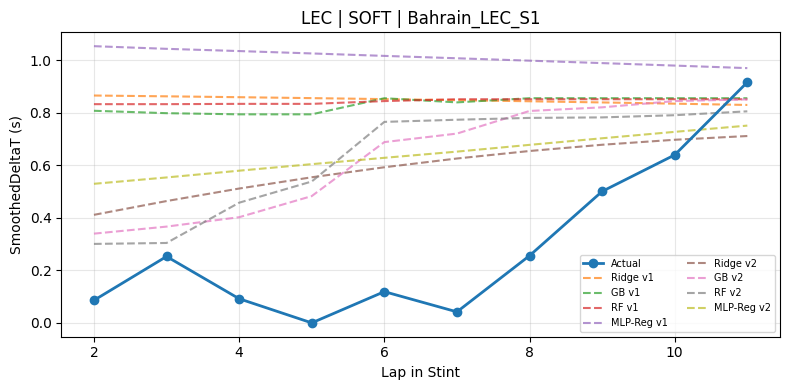

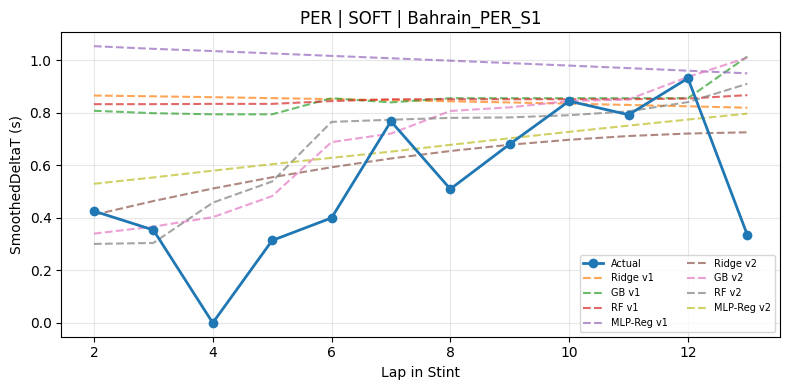

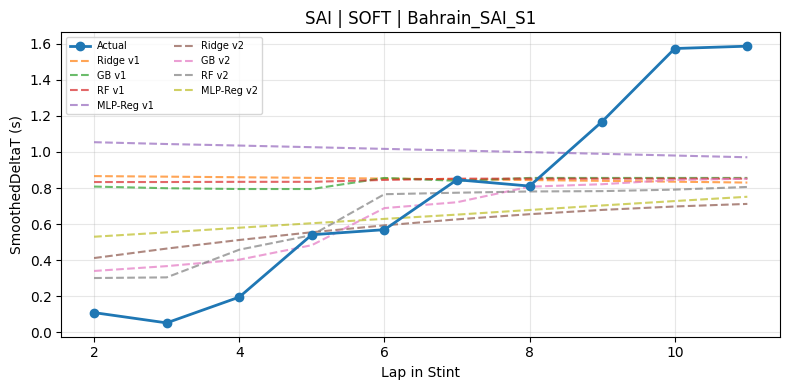

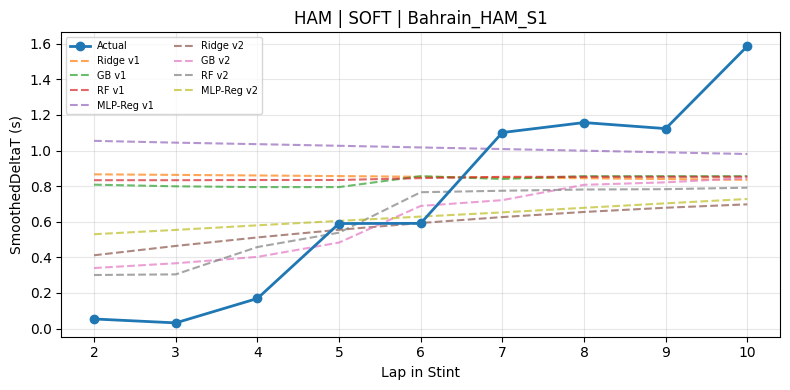

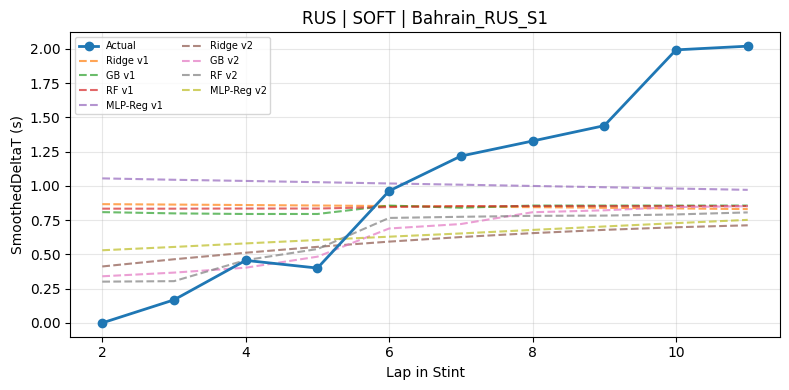

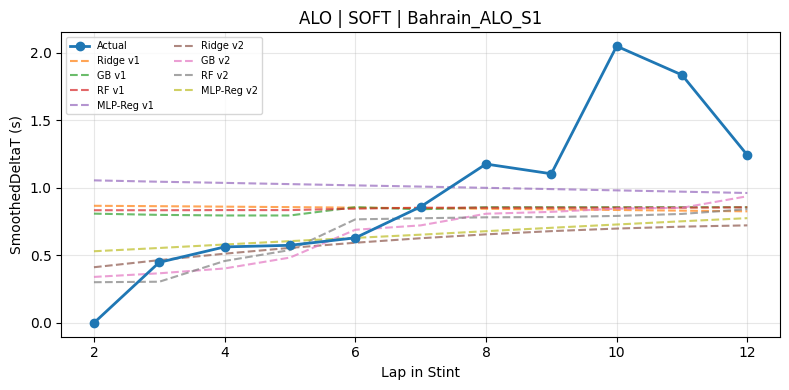

In [50]:
# %%
def plot_predicted_vs_actual_stints(df, models_and_preds, num_stints=6):
    stints = df['StintID'].unique()[:num_stints]

    for stint in stints:
        mask = df['StintID'] == stint
        stint_df = df[mask].sort_values('LapInStint')
        laps = stint_df['LapInStint'].values
        actual = stint_df['DeltaT'].values
        idx = stint_df.index.values  # integer positions in df_plot

        plt.figure(figsize=(8, 4))
        plt.plot(laps, actual, 'o-', linewidth=2, label='Actual', zorder=5)

        for label, y_pred_full in models_and_preds:
            plt.plot(laps, y_pred_full[idx], '--', alpha=0.7, label=label)

        compound = stint_df['Compound'].iloc[0]
        driver   = stint_df['Driver'].iloc[0]
        plt.title(f"{driver} | {compound} | {stint}")
        plt.xlabel("Lap in Stint")
        plt.ylabel("SmoothedDeltaT (s)")
        plt.legend(fontsize=7, ncol=2)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()


df_plot = df_oos23.reset_index(drop=True)

models_and_preds = [
    ("Ridge v1",   ridge1.predict(X_oos_v1)),
    ("GB v1",      gb1.predict(X_oos_v1)),
    ("RF v1",      rf1.predict(X_oos_v1)),
    ("MLP-Reg v1", predict_mlp_regressor(mlp_reg1, X_oos_v1_sc)),
    ("Ridge v2",   ridge2.predict(X_oos_v2)),
    ("GB v2",      gb2.predict(X_oos_v2)),
    ("RF v2",      rf2.predict(X_oos_v2)),
    ("MLP-Reg v2", predict_mlp_regressor(mlp_reg2, X_oos_v2_sc)),
]

plot_predicted_vs_actual_stints(df_plot, models_and_preds, num_stints=6)

## Final Insight

**Gap-only model (v1):** Generalises poorly to unseen races — stint position + compound alone
cannot capture track-level degradation behaviour. Out-of-sample R² is strongly negative.

**With race encoding:** Adding Race as a categorical feature captures track-specific effects
and substantially improves performance within the training distribution. Race encoding is a
proxy, however — it does not encode true track physics.

**Cross-season generalisation (2024 → 2023):** Even with race encoding, performance on a
different season remains weak due to distribution shift (car performance, setups, conditions).

**Telemetry-based cleanliness (v2):** Provides a richer, physics-informed signal for identifying
noisy laps. Whether this translates into better regression depends on telemetry coverage and
label quality.

**Conclusion:** True generalisation requires physically meaningful track-level features
(corner counts, average speed, grip proxy, etc.) rather than categorical race labels.

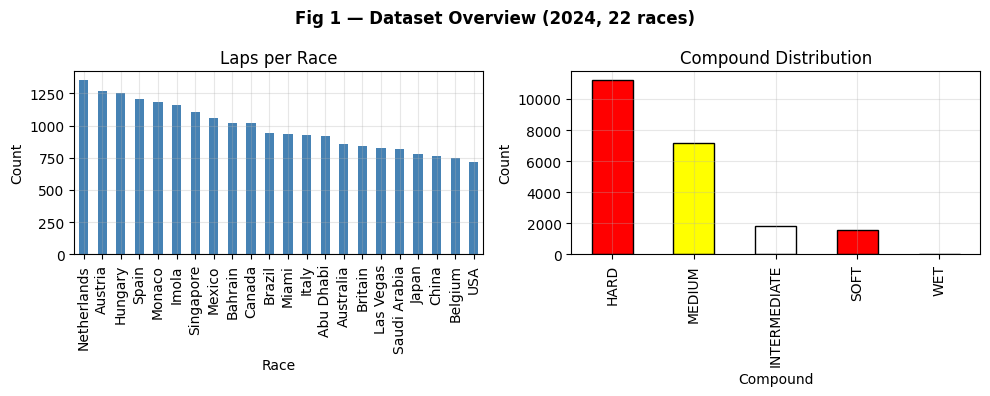

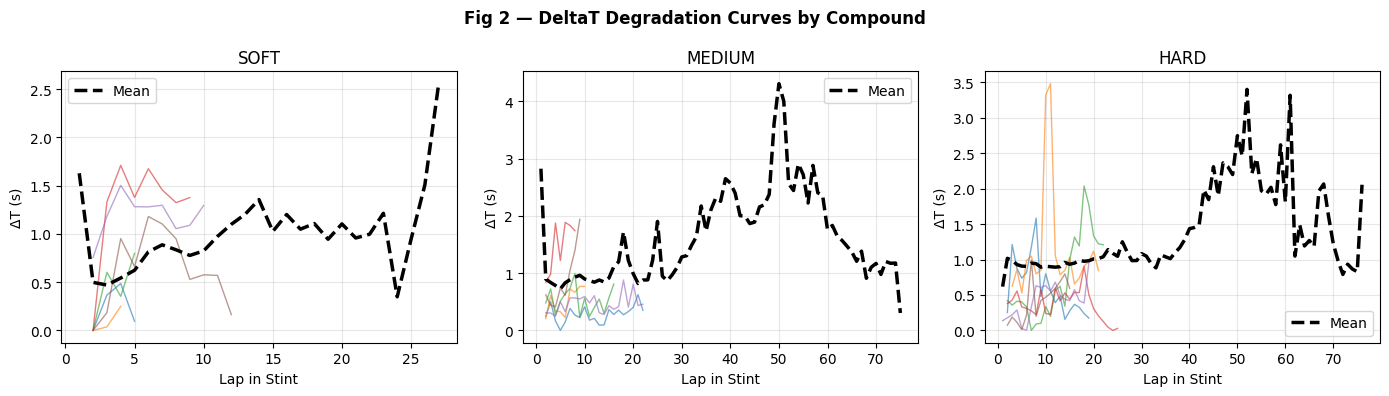

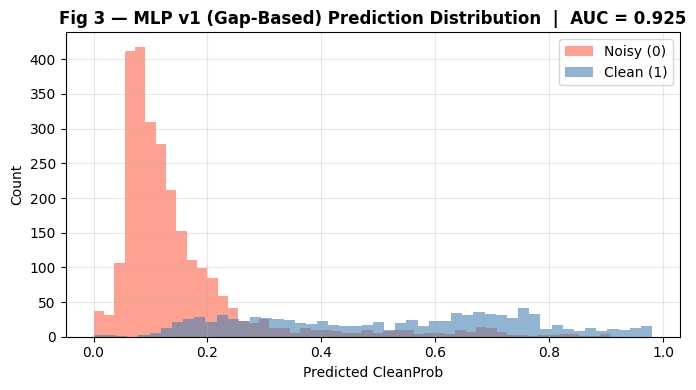

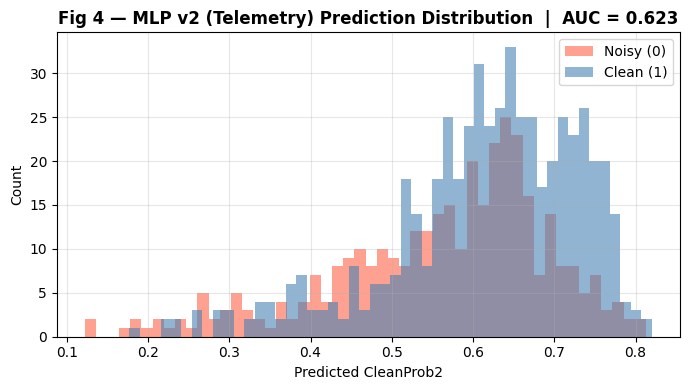

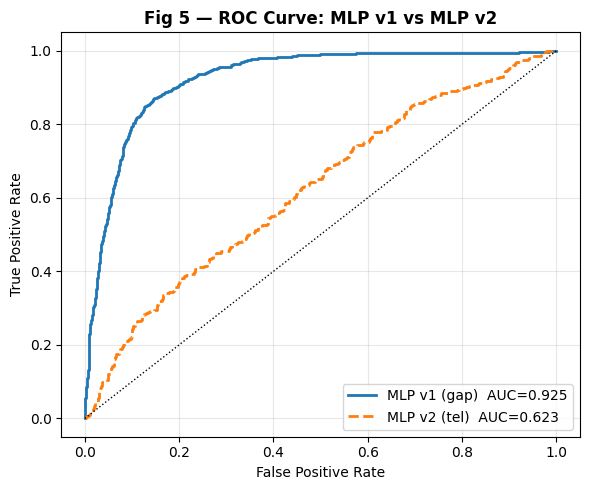

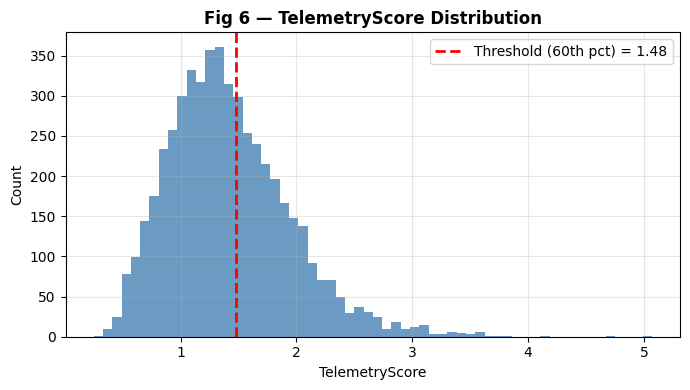

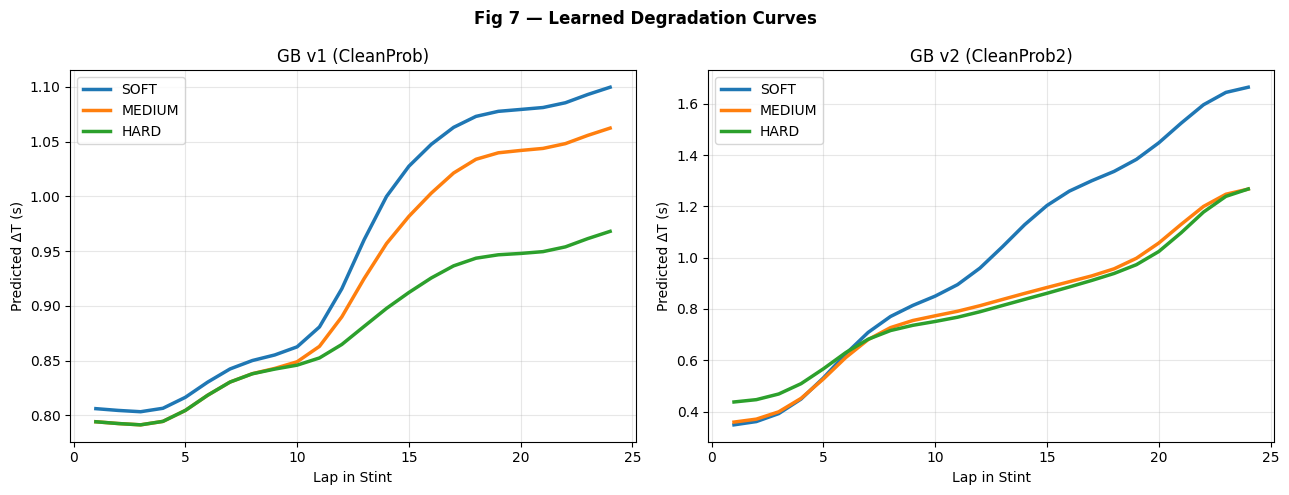

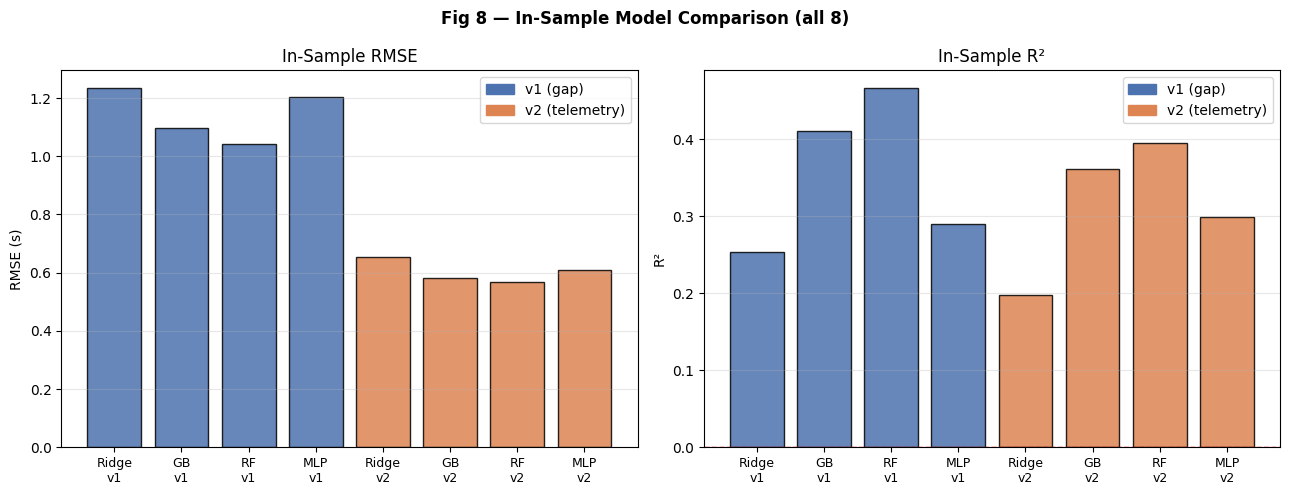

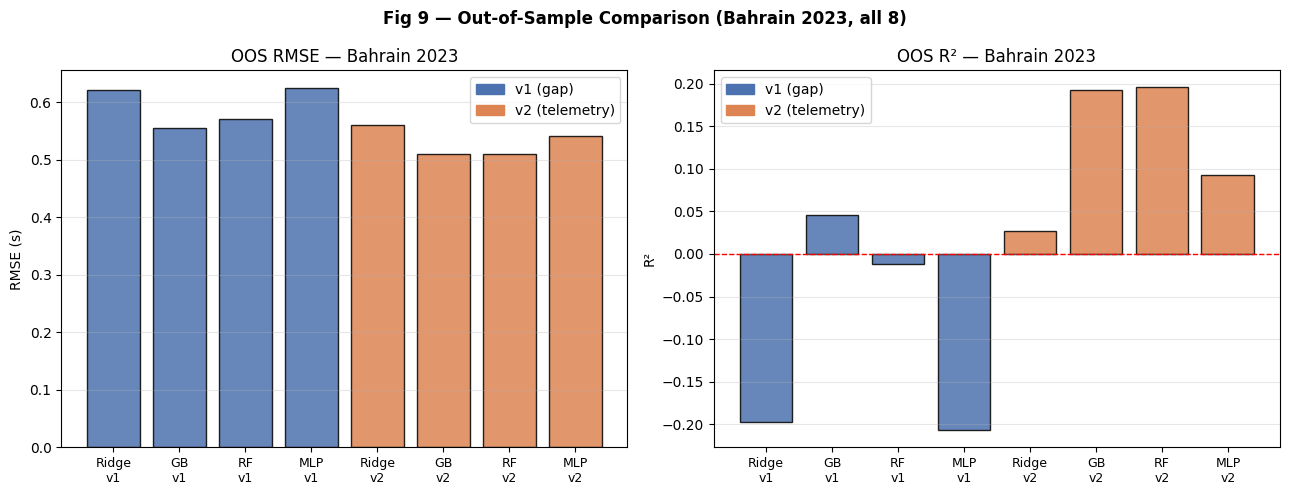

In [51]:
# %%
# ── ALL LATEX FIGURES — run this cell and screenshot each output ───────────────
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

save = False   # set True to save as .png instead of showing

def maybe_save(name):
    if save:
        plt.savefig(f"{name}.png", dpi=150, bbox_inches='tight')
    plt.show()


# ── Fig 1: Dataset overview ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['Race'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("Laps per Race"); axes[0].set_ylabel("Count"); axes[0].grid(alpha=0.3)
df['Compound'].value_counts().plot(kind='bar', ax=axes[1],
    color=['red','yellow','white'], edgecolor='black')
axes[1].set_title("Compound Distribution"); axes[1].set_ylabel("Count"); axes[1].grid(alpha=0.3)
plt.suptitle("Fig 1 — Dataset Overview (2024, 22 races)", fontweight='bold')
plt.tight_layout(); maybe_save("fig1_dataset_overview")


# ── Fig 2: DeltaT degradation curves per compound ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, comp in zip(axes, COMPOUNDS):
    subset = df_with_prob[df_with_prob['Compound'] == comp]
    stints = subset['StintID'].unique()[:6]
    for s in stints:
        sd = subset[subset['StintID'] == s].sort_values('LapInStint')
        ax.plot(sd['LapInStint'], sd['DeltaT'], alpha=0.6, linewidth=1)
    avg = subset.groupby('LapInStint')['DeltaT'].mean()
    ax.plot(avg.index, avg.values, 'k--', linewidth=2.5, label='Mean')
    ax.set_title(f"{comp}"); ax.set_xlabel("Lap in Stint")
    ax.set_ylabel("ΔT (s)"); ax.grid(alpha=0.3); ax.legend()
plt.suptitle("Fig 2 — DeltaT Degradation Curves by Compound", fontweight='bold')
plt.tight_layout(); maybe_save("fig2_degradation_curves")


# ── Fig 3: MLP v1 prediction distribution ─────────────────────────────────────
mlp1.eval()
with torch.no_grad():
    y_pred_v1 = mlp1(torch.tensor(X_te1, dtype=torch.float32)).numpy().flatten()
y_te1_arr = y_te1.values

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(y_pred_v1[y_te1_arr == 0], bins=50, alpha=0.6, label='Noisy (0)', color='tomato')
ax.hist(y_pred_v1[y_te1_arr == 1], bins=50, alpha=0.6, label='Clean (1)', color='steelblue')
auc1 = roc_auc_score(y_te1_arr, y_pred_v1)
ax.set_title(f"Fig 3 — MLP v1 (Gap-Based) Prediction Distribution  |  AUC = {auc1:.3f}",
             fontweight='bold')
ax.set_xlabel("Predicted CleanProb"); ax.set_ylabel("Count")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); maybe_save("fig3_mlp_v1_dist")


# ── Fig 4: MLP v2 prediction distribution ─────────────────────────────────────
mlp2.eval()
with torch.no_grad():
    y_pred_v2 = mlp2(torch.tensor(X_te2, dtype=torch.float32)).numpy().flatten()
y_te2_arr = y_te2.values

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(y_pred_v2[y_te2_arr == 0], bins=50, alpha=0.6, label='Noisy (0)', color='tomato')
ax.hist(y_pred_v2[y_te2_arr == 1], bins=50, alpha=0.6, label='Clean (1)', color='steelblue')
auc2 = roc_auc_score(y_te2_arr, y_pred_v2)
ax.set_title(f"Fig 4 — MLP v2 (Telemetry) Prediction Distribution  |  AUC = {auc2:.3f}",
             fontweight='bold')
ax.set_xlabel("Predicted CleanProb2"); ax.set_ylabel("Count")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); maybe_save("fig4_mlp_v2_dist")


# ── Fig 5: ROC curves v1 vs v2 side by side ───────────────────────────────────
fpr1, tpr1, _ = roc_curve(y_te1_arr, y_pred_v1)
fpr2, tpr2, _ = roc_curve(y_te2_arr, y_pred_v2)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr1, tpr1, label=f'MLP v1 (gap)  AUC={auc1:.3f}', linewidth=2)
ax.plot(fpr2, tpr2, label=f'MLP v2 (tel)  AUC={auc2:.3f}', linewidth=2, linestyle='--')
ax.plot([0,1],[0,1],'k:', linewidth=1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Fig 5 — ROC Curve: MLP v1 vs MLP v2", fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); maybe_save("fig5_roc_comparison")


# ── Fig 6: TelemetryScore distribution ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_tel['TelemetryScore'], bins=60, color='steelblue', alpha=0.8)
ax.axvline(tel_threshold, color='red', linestyle='--', linewidth=2,
           label=f'Threshold (60th pct) = {tel_threshold:.2f}')
ax.set_title("Fig 6 — TelemetryScore Distribution", fontweight='bold')
ax.set_xlabel("TelemetryScore"); ax.set_ylabel("Count")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); maybe_save("fig6_telemetry_score")


# ── Fig 7: Learned degradation curves — GB v1 and GB v2 side by side ──────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lap_range = np.arange(1, 25)

for ax, (model, encoder, label) in zip(axes, [
    (gb1, encoder1, "GB v1 (CleanProb)"),
    (gb2, encoder2, "GB v2 (CleanProb2)")
]):
    for comp in COMPOUNDS:
        X_num = np.column_stack([lap_range, lap_range**2])
        X_cat = encoder.transform([[comp, 'Bahrain']] * len(lap_range))
        y_pred = model.predict(np.hstack([X_num, X_cat]))
        y_pred = gaussian_filter1d(y_pred, sigma=1.5)
        ax.plot(lap_range, y_pred, linewidth=2.5, label=comp)
    ax.set_title(label); ax.set_xlabel("Lap in Stint")
    ax.set_ylabel("Predicted ΔT (s)"); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Fig 7 — Learned Degradation Curves", fontweight='bold')
plt.tight_layout(); maybe_save("fig7_degradation_learned")


# ── Fig 8: In-sample comparison bar chart ─────────────────────────────────────
labels_8 = ['Ridge\nv1','GB\nv1','RF\nv1','MLP\nv1',
             'Ridge\nv2','GB\nv2','RF\nv2','MLP\nv2']
rmse_vals = [
    np.sqrt(mean_squared_error(y_reg1, ridge1.predict(X_reg1))),
    np.sqrt(mean_squared_error(y_reg1, gb1.predict(X_reg1))),
    np.sqrt(mean_squared_error(y_reg1, rf1.predict(X_reg1))),
    np.sqrt(mean_squared_error(y_reg1, predict_mlp_regressor(mlp_reg1, X_reg1_sc))),
    np.sqrt(mean_squared_error(y_reg2, ridge2.predict(X_reg2))),
    np.sqrt(mean_squared_error(y_reg2, gb2.predict(X_reg2))),
    np.sqrt(mean_squared_error(y_reg2, rf2.predict(X_reg2))),
    np.sqrt(mean_squared_error(y_reg2, predict_mlp_regressor(mlp_reg2, X_reg2_sc))),
]
r2_vals = [
    r2_score(y_reg1, ridge1.predict(X_reg1)),
    r2_score(y_reg1, gb1.predict(X_reg1)),
    r2_score(y_reg1, rf1.predict(X_reg1)),
    r2_score(y_reg1, predict_mlp_regressor(mlp_reg1, X_reg1_sc)),
    r2_score(y_reg2, ridge2.predict(X_reg2)),
    r2_score(y_reg2, gb2.predict(X_reg2)),
    r2_score(y_reg2, rf2.predict(X_reg2)),
    r2_score(y_reg2, predict_mlp_regressor(mlp_reg2, X_reg2_sc)),
]

x = np.arange(8)
colors = ['#4C72B0']*4 + ['#DD8452']*4
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(x, rmse_vals, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_8, fontsize=9)
axes[0].set_ylabel("RMSE (s)"); axes[0].set_title("In-Sample RMSE")
axes[0].grid(axis='y', alpha=0.3)
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#4C72B0', label='v1 (gap)'),
                         Patch(color='#DD8452', label='v2 (telemetry)')])

axes[1].bar(x, r2_vals, color=colors, edgecolor='black', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels_8, fontsize=9)
axes[1].set_ylabel("R²"); axes[1].set_title("In-Sample R²")
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend(handles=[Patch(color='#4C72B0', label='v1 (gap)'),
                          Patch(color='#DD8452', label='v2 (telemetry)')])

plt.suptitle("Fig 8 — In-Sample Model Comparison (all 8)", fontweight='bold')
plt.tight_layout(); maybe_save("fig8_insample_comparison")


# ── Fig 9: OOS comparison bar chart (Bahrain 2023) ────────────────────────────
# requires df_oos23, X_oos_v1/v2, y_oos to be defined (Step 23 cell)
try:
    oos_rmse = [
        np.sqrt(mean_squared_error(y_oos, ridge1.predict(X_oos_v1))),
        np.sqrt(mean_squared_error(y_oos, gb1.predict(X_oos_v1))),
        np.sqrt(mean_squared_error(y_oos, rf1.predict(X_oos_v1))),
        np.sqrt(mean_squared_error(y_oos, predict_mlp_regressor(mlp_reg1, X_oos_v1_sc))),
        np.sqrt(mean_squared_error(y_oos, ridge2.predict(X_oos_v2))),
        np.sqrt(mean_squared_error(y_oos, gb2.predict(X_oos_v2))),
        np.sqrt(mean_squared_error(y_oos, rf2.predict(X_oos_v2))),
        np.sqrt(mean_squared_error(y_oos, predict_mlp_regressor(mlp_reg2, X_oos_v2_sc))),
    ]
    oos_r2 = [
        r2_score(y_oos, ridge1.predict(X_oos_v1)),
        r2_score(y_oos, gb1.predict(X_oos_v1)),
        r2_score(y_oos, rf1.predict(X_oos_v1)),
        r2_score(y_oos, predict_mlp_regressor(mlp_reg1, X_oos_v1_sc)),
        r2_score(y_oos, ridge2.predict(X_oos_v2)),
        r2_score(y_oos, gb2.predict(X_oos_v2)),
        r2_score(y_oos, rf2.predict(X_oos_v2)),
        r2_score(y_oos, predict_mlp_regressor(mlp_reg2, X_oos_v2_sc)),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].bar(x, oos_rmse, color=colors, edgecolor='black', alpha=0.85)
    axes[0].set_xticks(x); axes[0].set_xticklabels(labels_8, fontsize=9)
    axes[0].set_ylabel("RMSE (s)"); axes[0].set_title("OOS RMSE — Bahrain 2023")
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].legend(handles=[Patch(color='#4C72B0', label='v1 (gap)'),
                             Patch(color='#DD8452', label='v2 (telemetry)')])

    axes[1].bar(x, oos_r2, color=colors, edgecolor='black', alpha=0.85)
    axes[1].set_xticks(x); axes[1].set_xticklabels(labels_8, fontsize=9)
    axes[1].set_ylabel("R²"); axes[1].set_title("OOS R² — Bahrain 2023")
    axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].legend(handles=[Patch(color='#4C72B0', label='v1 (gap)'),
                             Patch(color='#DD8452', label='v2 (telemetry)')])

    plt.suptitle("Fig 9 — Out-of-Sample Comparison (Bahrain 2023, all 8)", fontweight='bold')
    plt.tight_layout(); maybe_save("fig9_oos_comparison")
except NameError:
    print("Run Step 23 cell first to generate OOS variables.")